# Model Analysis — 04

**Objetivo:** correr el pipeline train / val / test sin fuga de información,
comparar el baseline (mediana) contra XGBoost sobre validación, y evaluar el
modelo final sobre test. El tracking de experimentos con MLflow y el análisis
SHAP llegan en las fases 6 y 7.

**Entrada:** `data/processed/propiedades_argenprop_curado.csv`


## Configuración

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Bootstrap para importar `real_estate` (layout src/) sin instalar el paquete.
SRC_DIR = Path.cwd().parent / "src"
if not SRC_DIR.exists():
    SRC_DIR = Path.cwd() / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from real_estate.features import pipeline as pl  # noqa: E402
from real_estate.features import transformations as tr  # noqa: E402
from real_estate.models import entrenamiento as en  # noqa: E402

RUTA_CURADO = Path("../data/processed/propiedades_argenprop_curado.csv")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (9, 4.5)

## 1. Carga y split train / val / test

No se reutiliza `construir_features`: esa función codifica e imputa sobre todo
el dataset (útil para el EDA de la fase 4, pero fugaría información). Aquí el
preprocesamiento se ajusta **solo sobre train** y se reaplica a val/test.


In [2]:
df_curado = pd.read_csv(RUTA_CURADO, low_memory=False)
print(f"Curado: {df_curado.shape[0]:,} filas x {df_curado.shape[1]} columnas")

matriz = tr.crear_target_log(tr.seleccionar_columnas(df_curado))
print(f"Matriz con target log: {matriz.shape}")

train, val, test = pl.dividir_train_val_test(matriz, random_state=42)

print(f"\nTrain: {len(train):,} ({len(train) / len(matriz):.0%})")
print(f"Val:   {len(val):,} ({len(val) / len(matriz):.0%})")
print(f"Test:  {len(test):,} ({len(test) / len(matriz):.0%})")

Curado: 2,005 filas x 32 columnas
Descartadas 6 filas con precio inválido (< 1,000 USD).
Matriz con target log: (1999, 16)

Train: 1,599 (80%)
Val:   200 (10%)
Test:  200 (10%)


## 2. Preprocesamiento ajustado solo sobre train

`en.ajustar_preprocesamiento(train)` aprende sobre train el orden ordinal de
`barrio` / `tipo_propiedad` (por mediana de precio) y la mediana de imputación
de las numéricas. `en.aplicar_preprocesamiento` reaplica ese ajuste a cualquier
split: las categorías no vistas van a `CODIGO_DESCONOCIDO (-1)` y los NaN se
rellenan con la mediana del train.


In [3]:
ajustes = en.ajustar_preprocesamiento(train)

print(f"Categóricas con orden ordinal: {sorted(ajustes.ordenes)}")
print(f"Numéricas imputadas por mediana: {sorted(ajustes.imputador)}")

train_proc = en.aplicar_preprocesamiento(train, ajustes)
val_proc = en.aplicar_preprocesamiento(val, ajustes)
test_proc = en.aplicar_preprocesamiento(test, ajustes)

for nombre, sub in [("train", train_proc), ("val", val_proc), ("test", test_proc)]:
    print(f"{nombre}: {sub.shape} | NaN: {int(sub.isna().sum().sum())}")

Categóricas con orden ordinal: ['barrio', 'tipo_propiedad']
Numéricas imputadas por mediana: ['ambientes', 'antiguedad', 'banos', 'dormitorios', 'expensas_usd', 'superficie_cubierta']
train: (1599, 16) | NaN: 0
val: (200, 16) | NaN: 0
test: (200, 16) | NaN: 0


## 3. Features y target

In [4]:
X_train, y_train = en.separar_features_target(train_proc)
X_val, y_val = en.separar_features_target(val_proc)
X_test, y_test = en.separar_features_target(test_proc)

print(f"Features ({X_train.shape[1]}): {list(X_train.columns)}")
print("Target: log_precio_usd")

Features (14): ['superficie_cubierta', 'ambientes', 'dormitorios', 'banos', 'antiguedad', 'expensas_usd', 'expensas_informado', 'superficie_cubierta_informado', 'ambientes_informado', 'dormitorios_informado', 'banos_informado', 'antiguedad_informado', 'barrio_ordinal', 'tipo_propiedad_ordinal']
Target: log_precio_usd


## 4. Baseline (mediana)

Referencia mínima: predice siempre la mediana de `log_precio_usd` del train.
Si XGBoost no la supera, el problema no tiene señal aprovechable.


In [5]:
baseline = en.entrenar_baseline(X_train, y_train)

met_baseline = en.calcular_metricas(y_val, baseline.predict(X_val))
en.mostrar_metricas("baseline", met_baseline)

  baseline     | RMSE log: 0.6423 | RMSE USD:      185,135 | R²: -0.0025


## 5. XGBoost

In [6]:
xgb = en.entrenar_xgboost(X_train, y_train)

met_xgb_val = en.calcular_metricas(y_val, xgb.predict(X_val))
en.mostrar_metricas("xgboost", met_xgb_val)

  xgboost      | RMSE log: 0.2718 | RMSE USD:      112,963 | R²: 0.8205


## 6. Comparación en validación

In [7]:
comparacion = pd.DataFrame(
    {
        "baseline": met_baseline,
        "xgboost (val)": met_xgb_val,
    }
)
print(comparacion.round(4).to_string())

mejora = (1 - met_xgb_val["rmse_log"] / met_baseline["rmse_log"]) * 100
print(f"\nXGBoost reduce el RMSE log en {mejora:.1f}% respecto del baseline.")

             baseline  xgboost (val)
rmse_log       0.6423         0.2718
rmse_usd  185135.0405    112963.0096
r2            -0.0025         0.8205

XGBoost reduce el RMSE log en 57.7% respecto del baseline.


## 7. Modelo final sobre test

In [8]:
met_xgb_test = en.calcular_metricas(y_test, xgb.predict(X_test))
en.mostrar_metricas("xgboost (test)", met_xgb_test)

print(
    f"\nVal  vs Test (sobreajuste): RMSE log {met_xgb_val['rmse_log']:.4f} -> {met_xgb_test['rmse_log']:.4f}"
)

  xgboost (test) | RMSE log: 0.3040 | RMSE USD:       87,244 | R²: 0.7830

Val  vs Test (sobreajuste): RMSE log 0.2718 -> 0.3040


## 8. Predicciones vs reales (test)

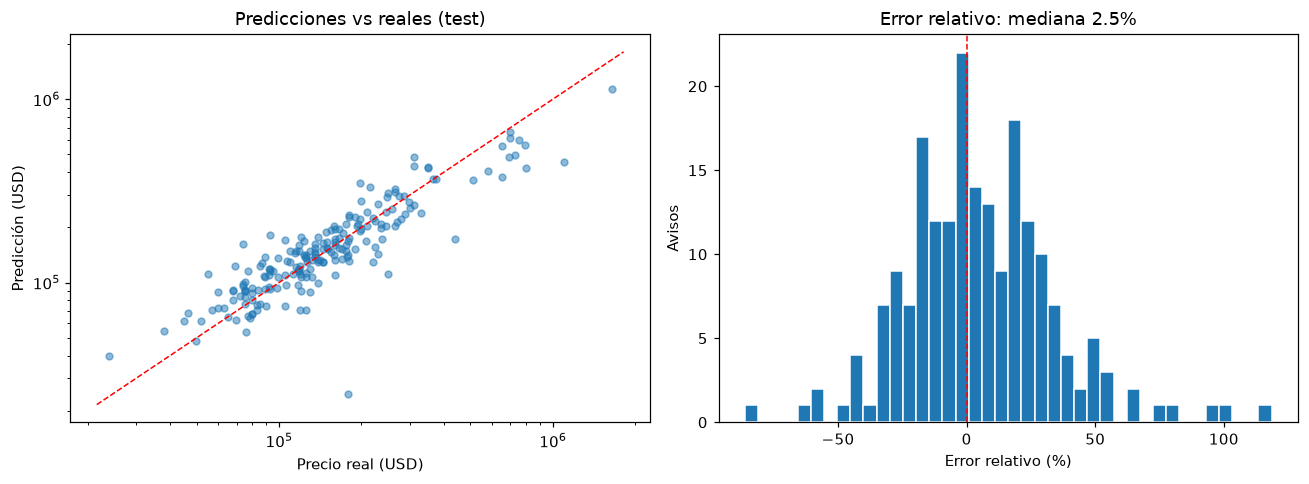

In [9]:
pred_usd = np.exp(xgb.predict(X_test))
real_usd = np.exp(y_test)
error_relativo = (pred_usd - real_usd) / real_usd * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

limites = [real_usd.min() * 0.9, real_usd.max() * 1.1]
axes[0].scatter(real_usd, pred_usd, alpha=0.5, s=20)
axes[0].plot(limites, limites, "r--", linewidth=1)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Precio real (USD)")
axes[0].set_ylabel("Predicción (USD)")
axes[0].set_title("Predicciones vs reales (test)")

axes[1].hist(error_relativo, bins=40, edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Error relativo (%)")
axes[1].set_ylabel("Avisos")
axes[1].set_title(f"Error relativo: mediana {np.median(error_relativo):.1f}%")

plt.tight_layout()
plt.show()

## 9. Importancia de features (XGBoost)

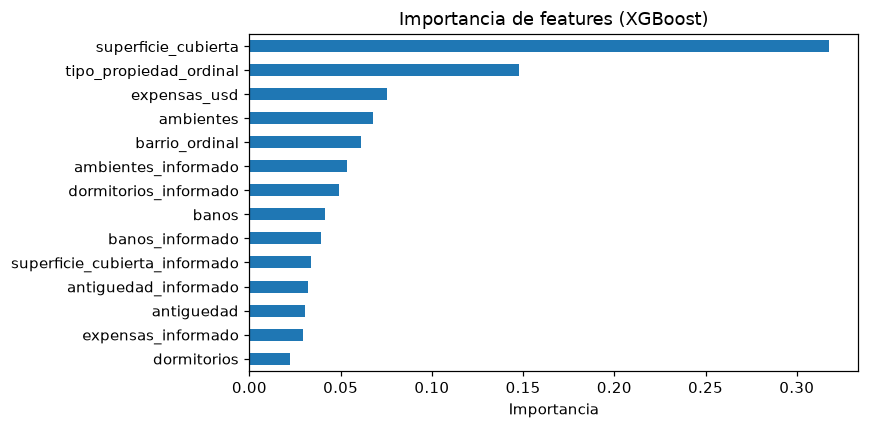

In [10]:
importancias = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(
    ascending=True
)

importancias.plot.barh(figsize=(8, 4))
plt.title("Importancia de features (XGBoost)")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

## 10. Conclusiones

In [11]:
print("Resumen del pipeline train/val/test (sin fuga):")
print(f"  baseline  | val : RMSE log {met_baseline['rmse_log']:.4f} | R² {met_baseline['r2']:.4f}")
print(f"  xgboost   | val : RMSE log {met_xgb_val['rmse_log']:.4f} | R² {met_xgb_val['r2']:.4f}")
print(f"  xgboost   | test: RMSE log {met_xgb_test['rmse_log']:.4f} | R² {met_xgb_test['r2']:.4f}")
print(f"  error relativo mediano en test: {np.median(error_relativo):.1f}%")
print("\nSiguiente: tracking de experimentos (MLflow, fase 6) y SHAP (fase 7).")

Resumen del pipeline train/val/test (sin fuga):
  baseline  | val : RMSE log 0.6423 | R² -0.0025
  xgboost   | val : RMSE log 0.2718 | R² 0.8205
  xgboost   | test: RMSE log 0.3040 | R² 0.7830
  error relativo mediano en test: 2.5%

Siguiente: tracking de experimentos (MLflow, fase 6) y SHAP (fase 7).
